## Indicadores fundamentales de desempeño operativo
## MTFB y MTTR

Para entender mejor el problema y el desempeño del equipo de mantenimiento, 
los indicadores
relevantes a considerar son el **MTBF** (Mean Time Between Failures) y el **MTTR** (Mean Time To Repair). 

**MTBF** (Mean Time Between Failures): es el tiempo promedio que transcurre entre una falla y la siguiente en un sistema o máquina.

- Un MTBF alto indica que la máquina es confiable y no falla con frecuencia. Es una medida de la confiabilidad del equipo.

- MTBF bajo indica fallas frecuentes.

**MTTR** (Mean Time To Repair): es el tiempo promedio que se tarda en reparar una máquina después de que ha fallado.
Es una medida de la eficiencia del equipo de mantenimiento.

- un MTTR alto sugiere problemas de diagnóstico, repuestos o procedimiento.

- Un MTTR bajo indica que las reparaciones se realizan rápidamente, minimizando el tiempo de inactividad. 

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [148]:
df = pd.read_parquet('../Dataset limpiado/dataset unificado.parquet')
df.shape

(140602, 33)

In [149]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,equipment,6661,int64,"[100268, 100312, 100884, 101632, 101638, 10172..."
1,operation,59,category,"[BIND LEG, BARTACK, SET SLEEVE, TOP STITCH HOO..."
2,wo_type,7,category,"[Corrective Maintenance, Breakdown, Preventati..."
3,base_model,119,category,"[VF2500, LT2-B872, W664, EX5214, VG2700, DLN54..."
4,problem_desc,24,category,"[It sews with defect / Cose con defecto, It do..."
5,failure_desc,38,category,[Machine head failure stopping sewing / Falla...
6,cause_desc,280,category,[Misadjusted machine head teeth / Dientes de c...
7,action_desc,278,category,[Adjust machine head teeth / Ajustar dientes d...
8,mechanic,185,category,"[Jaime Rivera, JERONIMO FUNEZ, Fabit Aranda, C..."
9,date,501,datetime64[ns],"[2023-10-03 00:00:00, 2024-01-17 00:00:00, 202..."


In [150]:
# Calculamos MTTR (downtime_gross) y MTBF (days_between_failures)
metricas_mes = df.groupby('mes').agg(
    mtbf=('days_between_failures', 'mean'),
    mttr=('downtime_gross_h', 'mean'),
    total_fallos=('equipment', 'count')
).reset_index()

In [151]:
metricas_mes['mes'] = metricas_mes['mes'].astype(str)
metricas_mes

,mes,mtbf,mttr,total_fallos
0,2023-01,1.428739,1.419347,5964
1,2023-02,3.488481,1.602844,10635
2,2023-03,5.289649,1.499130,12926
3,2023-04,8.722699,1.726956,6520
4,2023-05,8.619014,1.743074,11486
5,2023-06,8.228892,1.782593,12495
6,2023-07,10.335381,1.600787,10254
7,2023-08,13.907319,1.494860,8362
8,2023-09,13.421282,1.487550,8505
9,2023-10,14.657590,1.424375,7088


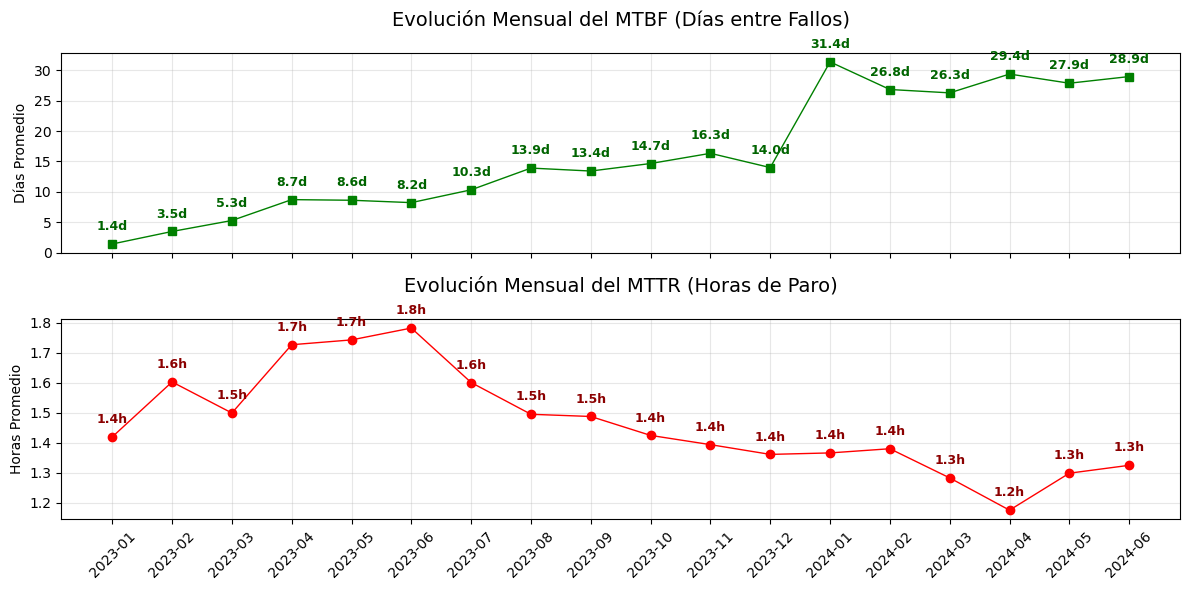

In [152]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Gráfico de MTBF (Confiabilidad de Máquinas)
ax1.plot(metricas_mes['mes'], metricas_mes['mtbf'], color='green', marker='s', linewidth=1)
ax1.set_title('Evolución Mensual del MTBF (Días entre Fallos)', fontsize=14, pad=20)
ax1.set_ylabel('Días Promedio')
ax1.set_xlabel('')
ax1.grid(True, alpha=0.3)

# Añadir etiquetas de datos para MTBF
for i, valor in enumerate(metricas_mes['mtbf']):
    ax1.annotate(f'{valor:.1f}d', 
                 (metricas_mes['mes'][i], metricas_mes['mtbf'][i]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=9, 
                 fontweight='bold',
                 color='darkgreen')

# Gráfico de MTTR (Eficiencia de Reparación)
ax2.plot(metricas_mes['mes'], metricas_mes['mttr'], marker='o', color='red', linewidth=1)
ax2.set_title('Evolución Mensual del MTTR (Horas de Paro)', fontsize=14, pad=20)
ax2.set_ylabel('Horas Promedio')
ax2.grid(True, alpha=0.3)

# Añadir etiquetas de datos para MTTR
for i, valor in enumerate(metricas_mes['mttr']):
    ax2.annotate(f'{valor:.1f}h', 
                 (metricas_mes['mes'][i], metricas_mes['mttr'][i]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=9, 
                 fontweight='bold',
                 color='darkred')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### MTBF: La Confiabilidad ha explotado
- ### Tendencia: ha pasado de fallos cada 1.4 días (enero 2023) a fallos cada 27.8 días (junio 2024).
- ### Interpretación: equipo es ahora mucho más confiables. Lo que antes era un caos diario (fallos casi cada 24 horas), ahora ocurre una vez al mes.

### MTTR: se ha mejorado la eficiencia en reparación


- ### Tendencia: el tiempo de reparación bajó de un pico de 1.8h (mediados de 2023) a 1.3h.<br>El MTTR se mantiene plano alrededor de 1.3h 
- ### Interpretación: con las herramientas, repuestos y personal actual, 1.3 horas es lo más rápido que pueden trabajar de forma sostenible.

In [178]:
# 1. Calcular el MTBF por modelo en los últimos 6 meses (donde se estancó el gráfico)
fecha_corte = df['date'].max() - pd.DateOffset(months=6)
df_reciente = df[df['date'] >= fecha_corte]

ranking_mtbf = df_reciente.groupby('base_model').agg(
    mtbf_modelo=('days_between_failures', 'mean'),
    total_fallos=('days_between_failures', 'count'),
    num_maquinas=('equipment', 'nunique')
).sort_values('mtbf_modelo')

# 2. Filtrar los que tienen un MTBF menor a 20 días (los que "frenan" el promedio)
modelos_problema = ranking_mtbf[ranking_mtbf['mtbf_modelo'] < 25]

print("--- MODELOS QUE IMPIDEN LLEGAR A LOS 40 DÍAS DE MTBF ---")
modelos_problema.head(10)

--- MODELOS QUE IMPIDEN LLEGAR A LOS 40 DÍAS DE MTBF ---


,mtbf_modelo,total_fallos,num_maquinas
base_model,,,
JK-8670BDII,1.000000,2,1
MJ2600SD,4.000000,83,10
LC62D-12,5.174956,1126,29
VC1700,5.206962,2643,78
VEU2703,5.866667,15,1
WT542,8.198675,302,15
2211EY6701,9.017857,56,3
WT562,9.479381,388,21
VE2713,10.339367,221,15


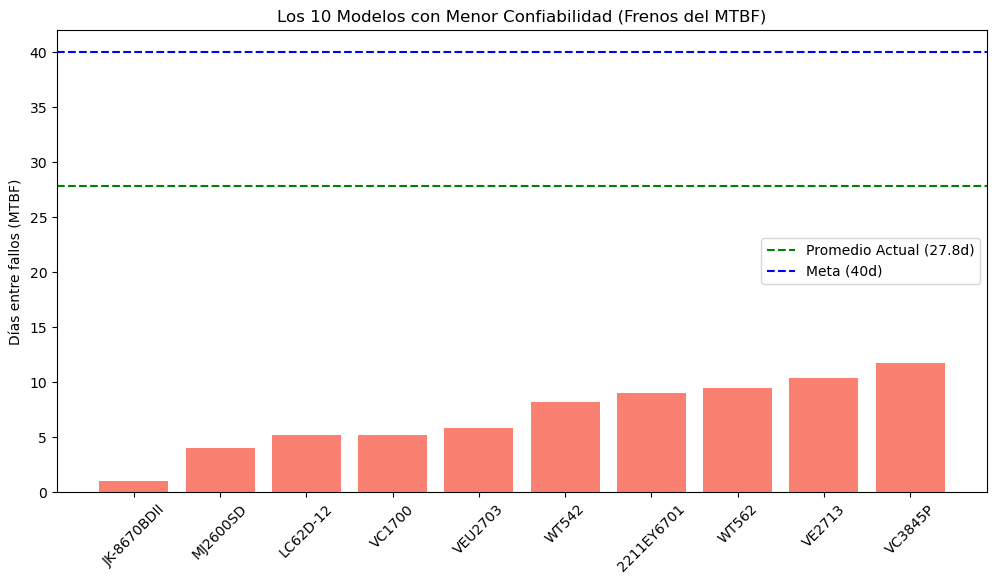

In [180]:
# Tomamos los 10 peores para visualizar
top_peores = modelos_problema.head(10)

plt.figure(figsize=(12,6))
bars = plt.bar(top_peores.index, top_peores['mtbf_modelo'], color='salmon')
plt.axhline(y=27.8, color='green', linestyle='--', label='Promedio Actual (27.8d)')
plt.axhline(y=40, color='blue', linestyle='--', label='Meta (40d)')

plt.title('Los 10 Modelos con Menor Confiabilidad (Frenos del MTBF)')
plt.ylabel('Días entre fallos (MTBF)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Distribución de modelos MTFB y MTTR por ultimos 6 meses

In [174]:
# Agrupamos por modelo base
df_modelos = df_reciente.groupby('base_model').agg(
    mttr_h=('downtime_gross', 'mean'),           # Tiempo medio de reparación
    mtbf_d=('days_between_failures', 'mean'),   # Tiempo medio entre fallos
    total_fallos=('equipment', 'count'),        # Volumen de fallos (para el tamaño del punto)
    num_maquinas=('equipment', 'nunique')       # Cantidad de máquinas de ese modelo
).reset_index()

# Opcional: Filtrar modelos con muy pocos fallos para limpiar el ruido
df_modelos = df_modelos[df_modelos['total_fallos'] > 12]

df_plot = df_modelos.copy()
top10 = df_plot.nlargest(10, 'total_fallos')['base_model']

df_plot['label_top10'] = np.where(
    df_plot['base_model'].isin(top10),
    df_plot['base_model'],
    ''
)

In [175]:
df_plot

,base_model,mttr_h,mtbf_d,total_fallos,num_maquinas,label_top10
0,2211EY6701,141.428571,9.017857,56,3,
4,83SP,48.400000,49.828571,35,9,
5,A4,36.704120,28.790262,267,38,
6,AZ8003,63.680851,29.638298,47,9,
8,AZ8403,38.172269,42.105042,238,47,
...,...,...,...,...,...,...
114,W600,39.727016,34.640736,707,132,
115,W664,81.837168,28.536283,1130,166,W664
116,WT500,79.404040,16.151515,99,8,
117,WT542,135.536424,8.198675,302,15,


In [177]:
fig = px.scatter(
    df_plot, 
    x='mtbf_d',       # Eje X: Confiabilidad (Días)
    y='mttr_h',       # Eje Y: Mantenibilidad (Horas)
    size='total_fallos', 
    color='num_maquinas',
    hover_name='base_model',
    text='label_top10',
    labels={
        'mtbf_d': 'MTBF (Días entre fallos) → MÁS ES MEJOR',
        'mttr_h': 'MTTR (Horas de reparación) → MENOS ES MEJOR'
    },
    title='Matriz de Desempeño por Modelo Base',
    width=1000, height=600
)

# Añadimos líneas de referencia (promedios generales)
fig.add_vline(x=df_modelos['mtbf_d'].median(), line_dash="dash", line_color="gray")
fig.add_hline(y=df_modelos['mttr_h'].median(), line_dash="dash", line_color="gray")

fig.update_traces(textposition='top center')
fig.show()

# Guardar como versión interactiva HTML
fig.write_html("matriz_de_desempeño.html")

### Cuadrante Inferior Derecho (LA ZONA DE ORO): <br>**MTBF Alto + MTTR Bajo**. <br>Los modelos más confiables y fáciles de arreglar.

### Cuadrante Superior Derecho (FIABLES PERO LENTOS):<br>**MTBF Alto + MTTR Alto**.<br>Fallan poco, pero cuando lo hacen, es un desastre (aquí están outliers ). Necesita mejorar repuestos o capacitación técnica para estos modelos.

### Cuadrante Inferior Izquierdo (LOS LATOSOS):<br>MTBF Bajo + MTTR Bajo.<br>Fallan constantemente pero se arreglan rápido. Son los que impiden que el MTBF suba a 40 días . Necesitan más mantenimiento preventivo.

### Cuadrante Superior Izquierdo:<br>**MTBF Bajo + MTTR Alto.**


Estan aqui por age, waiting_hours, parts_cost



Rediseño o Overhaul: Una reparación mayor profunda para resetear su ciclo de vida.
Stock Crítico: Si el MTTR es alto por espera, compre los repuestos antes de que falle y tenlos a pie de máquina.

### Distribición de modelos po MTFB y MTTR por todo el periodo (para comparar con lo de 6 ultimos meses)

In [157]:
# Agrupamos por modelo base
df_modelos = df.groupby('base_model').agg(
    mttr_h=('downtime_gross', 'mean'),           # Tiempo medio de reparación
    mtbf_d=('days_between_failures', 'mean'),   # Tiempo medio entre fallos
    total_fallos=('equipment', 'count'),        # Volumen de fallos (para el tamaño del punto)
    num_maquinas=('equipment', 'nunique')       # Cantidad de máquinas de ese modelo
).reset_index()

# Opcional: Filtrar modelos con muy pocos fallos para limpiar el ruido
df_modelos = df_modelos[df_modelos['total_fallos'] > 12] 
# df_modelos['ratio'] = df_modelos['total_fallos'] / df_modelos['num_maquinas']
df_modelos

,base_model,mttr_h,mtbf_d,total_fallos,num_maquinas
0,2211EY6701,170.739251,2.402219,721,4
1,504-E256,41.512195,25.707317,82,13
2,504-E51,70.977273,22.818182,44,8
3,504-ETS51,29.516129,24.935484,31,2
4,83SP,51.229268,10.714634,410,13
...,...,...,...,...,...
114,W600,42.827326,22.386047,1720,144
115,W664,70.300880,14.675930,5002,194
116,WT500,122.508065,8.255376,372,8
117,WT542,140.822695,4.916920,987,16


In [158]:
fig = px.scatter(
    df_modelos, 
    x='mtbf_d',       # Eje X: Confiabilidad (Días)
    y='mttr_h',       # Eje Y: Mantenibilidad (Horas)
    size='total_fallos', 
    color='num_maquinas',
    hover_name='base_model',
    labels={
        'mtbf_d': 'MTBF (Días entre fallos) → MÁS ES MEJOR',
        'mttr_h': 'MTTR (Horas de reparación) → MENOS ES MEJOR'
    },
    title='Matriz de Desempeño por Modelo Base',
    width=1000, height=600
)

# Añadimos líneas de referencia (promedios generales)
fig.add_vline(x=df_modelos['mtbf_d'].median(), line_dash="dash", line_color="gray")
fig.add_hline(y=df_modelos['mttr_h'].median(), line_dash="dash", line_color="gray")

fig.show()